# 🛒 Olist E-commerce Customer Segmentation (RFM Analysis)

### 📌 Project Overview
This project aims to analyze the customer base of **Olist**, the largest department store in Brazilian marketplaces. By applying the **RFM (Recency, Frequency, Monetary) Model**, we categorize customers into distinct segments to provide actionable marketing strategies.

### 🎯 Objective
- **Identify high-value customers** (Champions) to prioritize loyalty rewards.
- **Detect at-risk customers** who haven't purchased recently but were high spenders.
- **Optimize marketing spend** by differentiating strategies for each segment.

## 🛠️ Step 1: Data Engineering with SQL
To ensure **Data Integrity**, I used SQLite CTEs (Common Table Expressions) to:
1. **Filter valid orders:** Only 'delivered' status to reflect actual revenue.
2. **Handle Payment Aggregation:** Grouped payments by `order_id` *before* joining to avoid double-counting from multiple items per order.

Specific attention was paid to the order_payments table; payments were aggregated by order_id prior to joining to prevent revenue inflation caused by multiple items per order.

3. **Feature Engineering:** Calculated Recency (days since last purchase), Frequency (total orders), and Monetary (total spend) per unique customer.

## 📊 Step 2: RFM Scoring with NTILE
Using the `NTILE(5)` window function, customers are ranked from 1 to 5 for each metric:

- **Recency:** 5 is the most recent (Lower days = Higher score).
- **Frequency & Monetary:** 5 is the highest volume/spend.

**Segmentation Logic:**
- **Champions:** Total Score ≥ 13 (High R, F, and M).
- **At Risk:** Low Recency score (Haven't returned in a long time).
- **Promising/New:** High Recency but low Frequency.

In [15]:
import pandas as pd
import sqlite3
conn = sqlite3.connect('olist.db')

revenue_analysis_query = """
WITH valid_orders AS (
    -- select only completed order status
    SELECT 
        customer_id,
        order_id,
        order_purchase_timestamp
    FROM orders 
    WHERE order_status = 'delivered' 
      AND order_purchase_timestamp IS NOT NULL
),
order_payments_fixed AS (
    -- Grouped the payment_value by order_id to prevent double counting by order_items
    SELECT 
        order_id, 
        SUM(payment_value) as total_amount
    FROM order_payments
    GROUP BY order_id
),
rfm_raw AS (
    -- Combining customer information for RFM figures caluation
    SELECT 
        c.customer_unique_id,
        -- Recency: Latest purchase day
        (SELECT MAX(julianday(order_purchase_timestamp)) FROM orders) - MAX(julianday(o.order_purchase_timestamp)) AS recency,
        -- Frequency: Order accumulation by order_id
        COUNT(DISTINCT o.order_id) AS frequency,
        -- Monetary: Total amount for completed transaction
        SUM(p.total_amount) AS monetary
    FROM valid_orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_payments_fixed p ON o.order_id = p.order_id
    GROUP BY c.customer_unique_id
),
rfm_scores AS (
    -- Scoring each R,F and M into 1-5 
    SELECT 
        *,
        -- Recency Higher score at low value ( DESC )
        NTILE(5) OVER (ORDER BY recency DESC) as r_score,
        -- Frequency Higher score at high value ( ASC)
        NTILE(5) OVER (ORDER BY frequency) as f_score,
        -- Monetary Higher score at low value ( ASC)
        NTILE(5) OVER (ORDER BY monetary) as m_score
    FROM rfm_raw
),
labeled_rfm as (
    -- label customer according to rfm score
    select
    *,
    case 
        when (r_score + f_score + m_score) >= 13 then 'Champions'
        when r_score <=2 then 'At Risk'
        when f_score >=4 and m_score >=4 then 'Loyal Customers'
        when r_score >=4 and f_score <=2 then 'Promising / New'
        else 'About to Sleep'
        End as customer_segment
    from rfm_scores 
)
-- Aggregate revenue and customer count per segment
SELECT 
    customer_segment,
    count(*) as customer_count,
    round(sum(monetary),2) as total_revenue,
    round(avg(monetary),2) as avg_order_value
FROM labeled_rfm
group by 1
ORDER BY total_revenue DESC;       
"""

# 3. Create DataFrame for revenue analysis
df_revenue = pd.read_sql_query(revenue_analysis_query, conn)

# 4. close connection
conn.close()

print(df_revenue)

  customer_segment  customer_count  total_revenue  avg_order_value
0          At Risk           37344     6175426.47           165.37
1        Champions           14865     5500800.74           370.05
2   About to Sleep           19088     1668727.38            87.42
3  Loyal Customers            7659     1287767.56           168.14
4  Promising / New           14401      789739.62            54.84


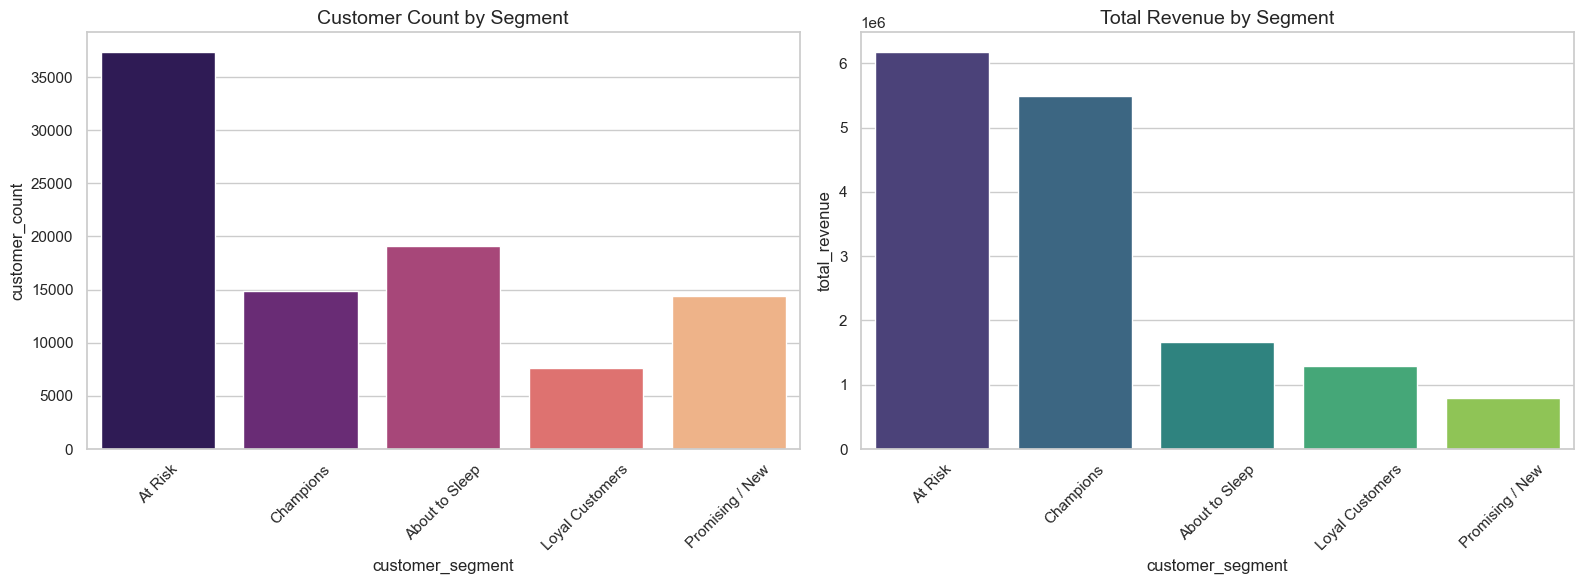

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Customer Count per Segment
sns.barplot(x='customer_segment', y='customer_count', data=df_revenue, ax=ax1, palette='magma', hue='customer_segment', legend=False)
ax1.set_title('Customer Count by Segment', fontsize=14)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Total Revenue per Segment
sns.barplot(x='customer_segment', y='total_revenue', data=df_revenue, ax=ax2, palette='viridis', hue='customer_segment', legend=False)
ax2.set_title('Total Revenue by Segment', fontsize=14)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 💡 Final Insights & Recommendations

Based on the visualization, here are the key findings:

1. **The Power of Champions:**
   - Although they represent only ~15% of the population, their **Average Order Value (AOV)** is over **$370**, significantly higher than other groups. 
   - *Action:* Implement exclusive VIP previews and loyalty points.

2. **The "Gold Mine" in At-Risk Customers:**
   - This group holds the highest total historical revenue ($6M+). They were once high-spenders but are drifting away.
   - *Action:* Trigger a **Retention Campaign** with high-value discount coupons (e.g., "We miss you! Here is 20% off").

3. **New Customer Conversion:**
   - The "Promising" segment has low AOV ($54). 
   - *Action:* Use **Up-selling** strategies or cross-category recommendations to increase their basket size.